In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import random
from torch.optim import LBFGS
from tqdm import tqdm

import os
import sys
current_dir = os.path.abspath('')
grandparent_dir = os.path.dirname(os.path.dirname(os.path.dirname(current_dir)))
if grandparent_dir not in sys.path:
    sys.path.append(grandparent_dir)

from util import get_data, get_n_params, make_pseudo_spacetime_cross_offsets, ModelTimeRecorder, RelativeL2ConvergenceTracker
from model.CaPITN import CaPITN


if not os.path.exists('results'):
    os.makedirs('results')

In [2]:
seed = 0
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

space_dim = 1
num_space = 3
space_step = 1e-2
num_step = 5
step_size = 1e-4

num_spatial_tokens = 1 + space_dim * (num_space - 1)
patch_length = num_step * num_spatial_tokens
spatial_radius = (num_space // 2) * space_step
c_max = spatial_radius / step_size

patch_offsets = torch.tensor(
    make_pseudo_spacetime_cross_offsets(
        space_dim,
        num_space=num_space,
        space_step=space_step,
        num_step=num_step,
        step=step_size,
    ),
    dtype=torch.float32,
    device=device,
)
assert patch_offsets.shape == (patch_length, space_dim + 1)
assert patch_offsets.dtype == torch.float32
assert patch_offsets.device.type == device.type

In [3]:
res, b_left, b_right, b_upper, b_lower = get_data([-1, 1], [0, 1], 256, 50)
res_test, _, _, _, _ = get_data([-1, 1], [0, 1], 512, 100)


def build_center(coords):
    coords = np.asarray(coords)
    assert coords.ndim == 2 and coords.shape[1] == space_dim + 1
    center = torch.tensor(coords[:, None, :], dtype=torch.float32, device=device)
    assert center.shape == (coords.shape[0], 1, space_dim + 1)
    return center


res = build_center(res)
b_left = build_center(b_left)
b_right = build_center(b_right)
b_upper = build_center(b_upper)
b_lower = build_center(b_lower)

x_res = res[:, :, 0:1].clone().detach().requires_grad_(True)
t_res = res[:, :, 1:2].clone().detach().requires_grad_(True)
assert x_res.is_leaf and t_res.is_leaf
assert x_res.shape == (res.shape[0], 1, space_dim)
assert t_res.shape == (res.shape[0], 1, 1)

x_left = b_left[:, :, 0:1]
t_left = b_left[:, :, 1:2]
x_right = b_right[:, :, 0:1]
t_right = b_right[:, :, 1:2]
x_upper = b_upper[:, :, 0:1]
t_upper = b_upper[:, :, 1:2]
x_lower = b_lower[:, :, 0:1]
t_lower = b_lower[:, :, 1:2]


def rigid_patch_grad(value, coordinate_center):
    token_grad = torch.autograd.grad(
        value,
        coordinate_center,
        grad_outputs=torch.ones_like(value),
        retain_graph=True,
        create_graph=True,
    )[0]
    return token_grad.sum(dim=1)


def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        m.bias.data.fill_(0.01)

In [4]:

k = nn.Parameter(torch.tensor([0.1], dtype=torch.float32, requires_grad=True, device=device))


In [5]:
from scipy.io import loadmat

mat = loadmat('./burgers_ref.mat')
x_ref = mat['X_star'][:, 0:1]
t_ref = mat['X_star'][:, 1:2]
u_ref = np.asarray(mat['u_star']).reshape(-1, 1)

data_coords = np.concatenate([x_ref, t_ref], axis=-1)
assert u_ref.ndim == 2 and u_ref.shape[1] == 1
assert u_ref.shape[0] == data_coords.shape[0], (
    f'u_ref has {u_ref.shape[0]} samples, but data_coords has {data_coords.shape[0]}'
)
data_center = build_center(data_coords)

x_data = data_center[:, :, 0:1]
t_data = data_center[:, :, 1:2]
u_data = torch.tensor(u_ref, dtype=torch.float32, device=device)
assert x_data.shape == (u_data.shape[0], 1, space_dim)
assert t_data.shape == (u_data.shape[0], 1, 1)
assert u_data.shape == (data_coords.shape[0], 1)

In [6]:
model = CaPITN(
    in_dim=2,
    d_model=32,
    n_heads=2,
    d_ff=512,
    n_layers=1,
    out_dim=1,
    c_max=c_max,
).to(device)

model.apply(init_weights)
trainable_parameters = tuple(model.parameters()) + (k,)
optim = LBFGS(trainable_parameters, line_search_fn='strong_wolfe')

print(model)
print(get_n_params(model))

CaPITN(
  (embedding): Linear(in_features=2, out_features=32, bias=True)
  (encoder): Encoder(
    (layers): ModuleList(
      (0): EncoderLayer(
        (attn): CharacteristicAwareAttention(
          (W_q): Linear(in_features=32, out_features=32, bias=True)
          (W_k): Linear(in_features=32, out_features=32, bias=True)
          (W_v): Linear(in_features=32, out_features=32, bias=True)
          (W_o): Linear(in_features=32, out_features=32, bias=True)
          (dropout): Dropout(p=0.0, inplace=False)
        )
        (ffn): Sequential(
          (0): Linear(in_features=32, out_features=256, bias=True)
          (1): WaveBiasAct()
          (2): Linear(in_features=256, out_features=32, bias=True)
        )
      )
    )
  )
  (decoder): Decoder(
    (layers): ModuleList(
      (0): DecoderLayer(
        (attn): CharacteristicAwareAttention(
          (W_q): Linear(in_features=32, out_features=32, bias=True)
          (W_k): Linear(in_features=32, out_features=32, bias=True)
  

In [7]:
relative_l2_threshold = 0.1
monitor_reference = u_data.detach().cpu().numpy().reshape(-1, 1)

def get_monitor_prediction():
    with torch.no_grad():
        prediction = model(x_data, t_data, patch_offsets)[:, 0, :]
    return prediction.reshape(-1, 1).cpu().numpy()

convergence_tracker = RelativeL2ConvergenceTracker(
    monitor_reference,
    relative_l2_threshold,
)
convergence_tracker.record(0.0, get_monitor_prediction())


1.9243489766852817

In [ ]:
time_recorder = ModelTimeRecorder(device)
loss_track = []
k_track = [k.item()]

for i in tqdm(range(500)):
    def closure():
        optim.zero_grad(set_to_none=True)

        u_res = model(x_res, t_res, patch_offsets)[:, 0, :]
        u_initial = model(x_left, t_left, patch_offsets)[:, 0, :]
        u_upper = model(x_upper, t_upper, patch_offsets)[:, 0, :]
        u_lower = model(x_lower, t_lower, patch_offsets)[:, 0, :]

        u_x = rigid_patch_grad(u_res, x_res)
        u_xx = rigid_patch_grad(u_x, x_res)
        u_t = rigid_patch_grad(u_res, t_res)

        loss_res = torch.mean((u_t + u_res * u_x - k * u_xx) ** 2)
        loss_bc = torch.mean((u_upper - u_lower) ** 2)
        x_initial = x_left[:, 0, :]
        loss_ic = torch.mean((u_initial + torch.sin(torch.pi * x_initial)) ** 2)

        u_data_pred = model(
            x_data,
            t_data,
            patch_offsets,
        )[:, 0, :]
        assert u_data_pred.shape == u_data.shape, (
            f'prediction shape {u_data_pred.shape} does not match target shape {u_data.shape}'
        )
        loss_data = torch.mean((u_data_pred - u_data) ** 2)

        loss = loss_res + loss_bc + loss_ic + loss_data
        if not torch.isfinite(loss).item():
            raise FloatingPointError(f'Non-finite total loss: {loss.item()}')

        loss_track.append([
            loss_res.item(),
            loss_bc.item(),
            loss_ic.item(),
            loss_data.item(),
        ])

        loss.backward(inputs=trainable_parameters)
        return loss

    with time_recorder.record_training():
        optim.step(closure)

    convergence_tracker.record(
        time_recorder.training_time,
        get_monitor_prediction(),
    )
    k_track.append(k.item())

100%|██████████| 500/500 [40:04<00:00,  4.81s/it]


In [9]:
np.save('./results/burgers_loss_capitn.npy', loss_track)
torch.save(model.state_dict(), './results/burgers_capitn.pt')
np.save('./results/burgers_k_capitn.npy', k_track)

print('Loss Res: {:4f}, Loss_BC: {:4f}, Loss_IC: {:4f}, Loss_Data: {:4f}'.format(loss_track[-1][0], loss_track[-1][1], loss_track[-1][2], loss_track[-1][3]))
print('Train Loss: {:4f}'.format(np.sum(loss_track[-1])))
print('Final k: {:4f}'.format(k_track[-1])) # 0.01/π ≈ 0.00318309886

print('Training Time: {:.2f} s'.format(time_recorder.training_time))

np.save(
    './results/burgers_relative_l2_error_vs_training_time_capitn.npy',
    convergence_tracker.as_array(),
)
if convergence_tracker.first_threshold_time is None:
    print('Relative L2 threshold {:.3f} was not reached.'.format(relative_l2_threshold))
else:
    print(
        'Relative L2 threshold {:.3f} first reached at {:.6f} s'.format(
            relative_l2_threshold,
            convergence_tracker.first_threshold_time,
        )
    )


Loss Res: 0.000056, Loss_BC: 0.000000, Loss_IC: 0.000008, Loss_Data: 0.000013
Train Loss: 0.000077
Final k: 0.003218
Training Time: 2388.69 s
Relative L2 threshold 0.100 first reached at 353.611106 s


Inference Time: 0.028319 s
relative L1 error: 0.001995
relative L2 error: 0.005762


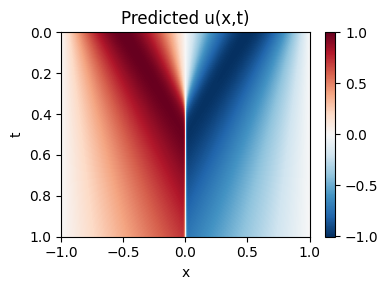

In [10]:
res_test = build_center(res_test)
x_test, t_test = res_test[:, :, 0:1], res_test[:, :, 1:2]
assert x_test.shape == (res_test.shape[0], 1, space_dim)
assert t_test.shape == (res_test.shape[0], 1, 1)

with time_recorder.record_inference():
    with torch.no_grad():
        pred = model(
            x_test,
            t_test,
            patch_offsets,
        )[:, 0, :]
        pred = pred.cpu().numpy()
print('Inference Time: {:.6f} s'.format(time_recorder.inference_time))

pred = pred.reshape(100, 512)

u = mat['u_star'].reshape(100, 512)
rl1 = np.sum(np.abs(u - pred)) / np.sum(np.abs(u))
rl2 = np.sqrt(np.sum((u - pred) ** 2) / np.sum(u ** 2))
print('relative L1 error: {:4f}'.format(rl1))
print('relative L2 error: {:4f}'.format(rl2))

plt.figure(figsize=(4, 3))
plt.imshow(pred, extent=[-1, 1, 1, 0], aspect='auto', cmap='RdBu_r')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Predicted u(x,t)')
plt.colorbar()
plt.tight_layout()
plt.savefig('./results/burgers_capitn_pred.png')
plt.show()

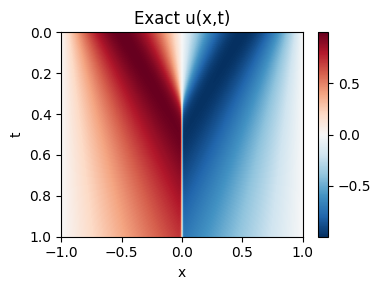

In [11]:
plt.figure(figsize=(4,3))
plt.imshow(u, extent=[-1,1,1,0], aspect='auto', cmap='RdBu_r')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Exact u(x,t)')
plt.colorbar()
plt.tight_layout()
plt.savefig('./results/burgers_exact.png')
plt.show()

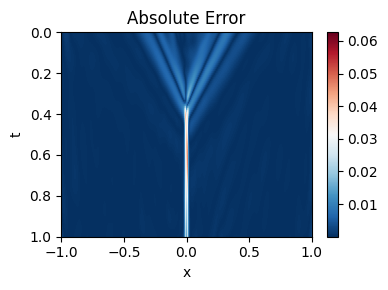

In [12]:
plt.figure(figsize=(4,3))
plt.imshow(np.abs(pred - u), extent=[-1,1,1,0], aspect='auto', cmap='RdBu_r')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Absolute Error')
plt.colorbar()
plt.tight_layout()
plt.savefig('./results/burgers_capitn_error.png')
plt.show()

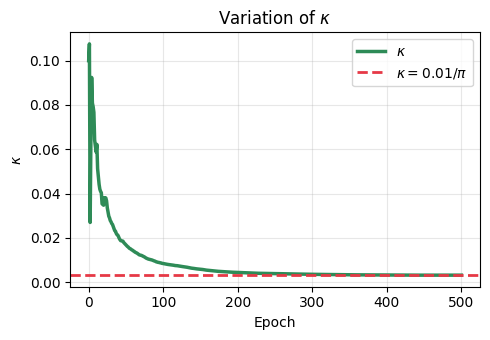

In [13]:
plt.figure(figsize=(5, 3.5))
plt.plot(k_track, label=r'$\kappa$', color='#2E8B57', linewidth=2.5)
plt.axhline(
    y=0.01 / np.pi,
    color='#E63946',
    linestyle='--',
    linewidth=2,
    label=r'$\kappa=0.01/\pi$',
)
plt.xlabel('Epoch')
plt.ylabel(r'$\kappa$')
plt.title(r'Variation of $\kappa$')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

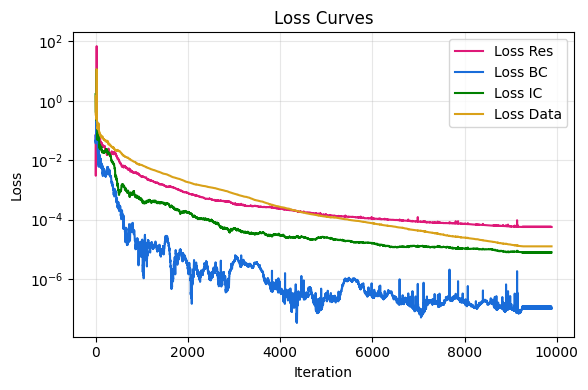

In [14]:

loss_track = np.array(loss_track)
plt.figure(figsize=(6,4))
plt.plot(loss_track[:,0], label='Loss Res', color="#de1978")
plt.plot(loss_track[:,1], label='Loss BC', color="#196cd9") 
plt.plot(loss_track[:,2], label='Loss IC', color="green")
plt.plot(loss_track[:,3], label='Loss Data', color="#d9a119")
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Loss Curves')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()